In [1]:
import os
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
with open("data_split.json", "r") as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 1000
Validation: 125
Test: 126


In [3]:
train_data = r"Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [4]:
def preprocess_t2f(image):
    # Expected original BraTS shape
    if image.shape != (240, 240, 155):
        raise ValueError(
            f"Unexpected image shape: {image.shape}"
        )

    # Crop
    image = image[16:224, 8:232, :]

    # Pad depth from 155 to 160
    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    # Foreground mask before intensity transformation
    foreground = image > 0

    if not np.any(foreground):
        raise ValueError(
            "No foreground voxels found"
        )

    # Robust upper intensity limit
    upper = np.percentile(
        image[foreground],
        99.9
    )

    # Clip outliers
    image = np.clip(
        image,
        0,
        upper
    )

    # Scale to [0, 1]
    image = image / upper

    # Scale entire volume to [-1, 1]
    image = image * 2.0 - 1.0

    return image.astype(np.float32)

In [5]:
def preprocess_mask(mask):
    # Expected original BraTS shape
    if mask.shape != (240, 240, 155):
        raise ValueError(f"Unexpected mask shape: {mask.shape}")

    # Apply exactly the same spatial crop as T2f
    mask = mask[16:224, 8:232, :]

    # Apply exactly the same z-padding as T2f
    mask = np.pad(
        mask,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    return mask.astype(np.int64)

In [6]:
def calculate_tumour_entropy(image, mask, num_bins=256):
    # Whole tumour = all non-zero tumour labels
    tumour_region = mask > 0

    if not np.any(tumour_region):
        raise ValueError("No tumour voxels found")

    tumour_values = image[tumour_region]

    # T2f has already been normalized to [0, 1]
    tumour_values = np.clip(tumour_values, 0.0, 1.0)

    hist, _ = np.histogram(
        tumour_values,
        bins=num_bins,
        range=(0.0, 1.0),
        density=False
    )

    probabilities = hist.astype(np.float64)
    probabilities = probabilities / probabilities.sum()

    probabilities = probabilities[probabilities > 0]

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return np.float32(entropy)

In [7]:
from torch.utils.data import Dataset, DataLoader

class BraTSDataset(Dataset):
    def __init__(self, subjects, data_dir):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        subject = self.subjects[idx]
        subject_path = os.path.join(self.data_dir, subject)

        files = os.listdir(subject_path)

        t2f_file = [f for f in files if "t2f" in f.lower()][0]
        seg_file = [f for f in files if "seg" in f.lower()][0]

        # Load T2f
        image = nib.load(
            os.path.join(subject_path, t2f_file)
        ).get_fdata()

        # Load segmentation
        mask = nib.load(
            os.path.join(subject_path, seg_file)
        ).get_fdata()

        # Apply preprocessing
        image = preprocess_t2f(image)
        mask = preprocess_mask(mask)

        # Calculate whole-tumour Shannon entropy
        entropy = calculate_tumour_entropy(
            image,
            mask
        )

        # Convert to tensors
        image = torch.from_numpy(
            image
        ).float().unsqueeze(0)

        mask = torch.from_numpy(
            mask
        ).long().unsqueeze(0)

        entropy = torch.tensor(
            entropy,
            dtype=torch.float32
        )

        return {
            "image": image,
            "mask": mask,
            "heterogeneity": entropy,
            "subject": subject
        }

In [8]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))

Dataset size: 1000


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

In [10]:
sample = train_dataset[0]

print("Subject:", sample["subject"])
print("Image:", sample["image"].shape)
print("Mask:", sample["mask"].shape)
print("Mask labels:", torch.unique(sample["mask"]))
print("Heterogeneity:", sample["heterogeneity"])
print("Heterogeneity shape:", sample["heterogeneity"].shape)

Subject: BraTS-GLI-00240-000
Image: torch.Size([1, 208, 224, 160])
Mask: torch.Size([1, 208, 224, 160])
Mask labels: tensor([0, 1, 2, 3])
Heterogeneity: tensor(7.3900)
Heterogeneity shape: torch.Size([])


In [11]:
import numpy as np

entropy_values = []
tumour_volumes = []
subject_ids = []

for i in range(len(train_dataset)):
    sample = train_dataset[i]

    image_np = sample["image"][0].numpy()
    mask_np = sample["mask"][0].numpy()

    entropy = calculate_tumour_entropy(
        image_np,
        mask_np
    )

    # Whole tumour volume in voxels
    tumour_volume = np.sum(mask_np > 0)

    entropy_values.append(entropy)
    tumour_volumes.append(tumour_volume)
    subject_ids.append(sample["subject"])

entropy_values = np.array(entropy_values)
tumour_volumes = np.array(tumour_volumes)

print("Number of subjects:", len(entropy_values))

print("\nEntropy:")
print("Min:", entropy_values.min())
print("Max:", entropy_values.max())
print("Mean:", entropy_values.mean())
print("Median:", np.median(entropy_values))
print("Std:", entropy_values.std())

print("\nPercentiles:")
print("P10:", np.percentile(entropy_values, 10))
print("P25:", np.percentile(entropy_values, 25))
print("P50:", np.percentile(entropy_values, 50))
print("P75:", np.percentile(entropy_values, 75))
print("P90:", np.percentile(entropy_values, 90))

correlation = np.corrcoef(
    entropy_values,
    tumour_volumes
)[0, 1]

print("\nEntropy vs tumour volume correlation:")
print(correlation)

Number of subjects: 1000

Entropy:
Min: 0.00014148682
Max: 7.9429145
Mean: 6.958757
Median: 7.3017635
Std: 1.027493

Percentiles:
P10: 5.7544723
P25: 6.812013
P50: 7.3017635
P75: 7.57687
P90: 7.7191477

Entropy vs tumour volume correlation:
0.01644660647368779


In [12]:
timesteps = 1000

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, timesteps)

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

In [13]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2

        embeddings = math.log(10000) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings
        )

        embeddings = t[:, None] * embeddings[None, :]

        embeddings = torch.cat(
            (embeddings.sin(), embeddings.cos()),
            dim=1
        )

        return embeddings

In [14]:
class ResBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv1 = nn.Conv3d(
            in_channels, out_channels,
            kernel_size=3, padding=1
        )

        self.conv2 = nn.Conv3d(
            out_channels, out_channels,
            kernel_size=3, padding=1
        )

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:
            self.residual = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x, t):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        time_emb = self.time_mlp(t)
        time_emb = time_emb[:, :, None, None, None]

        h = h + time_emb

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + self.residual(x)

In [15]:
class DownBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.resblock = ResBlock3D(
            in_channels,
            out_channels,
            time_dim
        )

        self.downsample = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t):
        h = self.resblock(x, t)

        down = self.downsample(h)

        return h, down


class UpBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        time_dim
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.resblock = ResBlock3D(
            out_channels + skip_channels,
            out_channels,
            time_dim
        )

    def forward(self, x, skip, t):
        x = self.upsample(x)

        x = torch.cat([x, skip], dim=1)

        x = self.resblock(x, t)

        return x

In [16]:
class ConditionalUNet3D(nn.Module):
    def __init__(
        self,
        image_channels=1,
        mask_channels=3,
        out_channels=1,
        base_channels=16,
        time_dim=128
    ):
        super().__init__()

        # Timestep embedding
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        # Continuous heterogeneity scalar -> embedding
        self.heterogeneity_embedding = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        # Noisy T2f + 3 tumour-mask channels
        total_in_channels = image_channels + mask_channels

        self.input_conv = nn.Conv3d(
            total_in_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        self.down1 = DownBlock3D(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.down2 = DownBlock3D(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.down3 = DownBlock3D(
            base_channels * 4,
            base_channels * 8,
            time_dim
        )

        self.mid = ResBlock3D(
            base_channels * 8,
            base_channels * 8,
            time_dim
        )

        self.up3 = UpBlock3D(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 4,
            time_dim=time_dim
        )

        self.up2 = UpBlock3D(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 2,
            time_dim=time_dim
        )

        self.up1 = UpBlock3D(
            in_channels=base_channels * 2,
            skip_channels=base_channels * 2,
            out_channels=base_channels,
            time_dim=time_dim
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x, t, mask, heterogeneity):

        # -------------------------
        # 1. Multi-class mask 
        # -------------------------

        # Dataset gives:
        # mask shape = [B, 1, D, H, W]
        # labels = 0, 1, 2, 3

        mask = mask.squeeze(1)

        # One-hot gives [B, D, H, W, 4]
        mask_onehot = F.one_hot(
            mask.long(),
            num_classes=4
        )

        # -> [B, 4, D, H, W]
        mask_onehot = mask_onehot.permute(
            0, 4, 1, 2, 3
        ).float()

        # Remove background channel
        # -> [B, 3, D, H, W]
        mask_onehot = mask_onehot[:, 1:, ...]

        # Combine noisy T2f + tumour mask
        x = torch.cat(
            [x, mask_onehot],
            dim=1
        )

        # -------------------------
        # 2. Timestep embedding
        # -------------------------

        t_emb = self.time_embedding(t)

        # -------------------------
        # 3. Heterogeneity embedding
        # -------------------------

        # DataLoader gives approximately [B]
        heterogeneity = heterogeneity.float().view(-1, 1)

        h_emb = self.heterogeneity_embedding(
            heterogeneity
        )

        # Combine global conditions
        condition_emb = t_emb + h_emb

        # -------------------------
        # 4. UNet
        # -------------------------

        x = self.input_conv(x)

        skip1, x = self.down1(x, condition_emb)
        skip2, x = self.down2(x, condition_emb)
        skip3, x = self.down3(x, condition_emb)

        x = self.mid(x, condition_emb)

        x = self.up3(x, skip3, condition_emb)
        x = self.up2(x, skip2, condition_emb)
        x = self.up1(x, skip1, condition_emb)

        x = self.output_conv(x)

        return x

In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ConditionalUNet3D(
    image_channels=1,
    mask_channels=3,
    out_channels=1,
    base_channels=16,
    time_dim=128
).to(device)

print(
    "Number of parameters:",
    sum(p.numel() for p in model.parameters())
)

Number of parameters: 4542385


In [18]:
sample = train_dataset[0]

image = sample["image"].unsqueeze(0).to(device)
mask = sample["mask"].unsqueeze(0).to(device)
heterogeneity = sample["heterogeneity"].unsqueeze(0).to(device)

# Random diffusion timestep
t = torch.randint(
    0,
    timesteps,
    (1,),
    device=device
)

# For this smoke test, use the image as x input
with torch.no_grad():
    output = model(
        image,
        t,
        mask,
        heterogeneity
    )

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Heterogeneity shape:", heterogeneity.shape)
print("Output shape:", output.shape)

Image shape: torch.Size([1, 1, 208, 224, 160])
Mask shape: torch.Size([1, 1, 208, 224, 160])
Heterogeneity shape: torch.Size([1])
Output shape: torch.Size([1, 1, 208, 224, 160])


In [18]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    device = x0.device

    sqrt_alpha_cumprod_device = sqrt_alphas_cumprod.to(device)
    sqrt_one_minus_alpha_cumprod_device = (
        sqrt_one_minus_alphas_cumprod.to(device)
    )

    sqrt_alpha_hat = (
        sqrt_alpha_cumprod_device[t]
        .view(-1, 1, 1, 1, 1)
    )

    sqrt_one_minus_alpha_hat = (
        sqrt_one_minus_alpha_cumprod_device[t]
        .view(-1, 1, 1, 1, 1)
    )

    xt = (
        sqrt_alpha_hat * x0
        + sqrt_one_minus_alpha_hat * noise
    )

    return xt, noise

In [19]:
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }, path)


def load_checkpoint(model, optimizer, path, device):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return checkpoint["epoch"]

In [20]:
def train_ddpm(
    model,
    train_loader,
    epochs,
    optimizer,
    device,
    checkpoint_dir="conditional_checkpoints"
):
    import os

    os.makedirs(checkpoint_dir, exist_ok=True)

    model.train()

    loss_history = []

    # Move diffusion schedule to the same device once
    sqrt_alpha_cumprod_device = sqrt_alphas_cumprod.to(device)
    sqrt_one_minus_alpha_cumprod_device = (
        sqrt_one_minus_alphas_cumprod.to(device)
    )

    # Training-set Shannon entropy statistics
    entropy_mean = 6.870206
    entropy_std = 0.3320367

    for epoch in range(epochs):
        epoch_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):

            # T2f image
            x0 = batch["image"].to(device)

            # Conditional inputs
            mask = batch["mask"].to(device)
            heterogeneity = batch["heterogeneity"].to(device)

            # Z-score normalization of Shannon entropy
            heterogeneity = (
                heterogeneity - entropy_mean
            ) / entropy_std

            # Random diffusion timestep
            t = torch.randint(
                0,
                timesteps,
                (x0.shape[0],),
                device=device
            )

            # Random Gaussian noise
            noise = torch.randn_like(x0)

            sqrt_alpha_hat = (
                sqrt_alpha_cumprod_device[t]
                .view(-1, 1, 1, 1, 1)
            )

            sqrt_one_minus_alpha_hat = (
                sqrt_one_minus_alpha_cumprod_device[t]
                .view(-1, 1, 1, 1, 1)
            )

            # Forward diffusion
            xt = (
                sqrt_alpha_hat * x0
                + sqrt_one_minus_alpha_hat * noise
            )

            # Conditional noise prediction
            predicted_noise = model(
                xt,
                t,
                mask,
                heterogeneity
            )

            # DDPM noise-prediction loss
            loss = F.mse_loss(
                predicted_noise,
                noise
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if (batch_idx + 1) % 10 == 0:
                print(
                    f"Epoch {epoch + 1}/{epochs} | "
                    f"Batch {batch_idx + 1}/{len(train_loader)} | "
                    f"Loss: {loss.item():.4f}"
                )

        avg_loss = epoch_loss / len(train_loader)

        loss_history.append(avg_loss)

        print(
            f"Epoch {epoch + 1} completed | "
            f"Average loss: {avg_loss:.4f}"
        )

        # Save checkpoint after every epoch
        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"conditional_ddpm_epoch_{epoch + 1:03d}.pt"
        )

        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch + 1,
            path=checkpoint_path
        )

        print("Saved:", checkpoint_path)

        np.save(
            os.path.join(
                checkpoint_dir,
                "conditional_ddpm_loss_history.npy"
            ),
            np.array(loss_history)
        )

In [21]:
@torch.no_grad()
def sample_conditional_ddpm(
    model,
    shape,
    mask,
    heterogeneity,
    device
):
    model.eval()

    # Move conditions to device
    mask = mask.to(device)

    heterogeneity = (
        heterogeneity
        .to(device)
        .float()
    )

    # Same entropy normalization as training
    entropy_mean = 6.870206
    entropy_std = 0.3320367

    heterogeneity = (
        heterogeneity - entropy_mean
    ) / entropy_std

    # Move diffusion schedule to device once
    betas_device = betas.to(device)
    alphas_device = alphas.to(device)
    alphas_cumprod_device = (
        alphas_cumprod.to(device)
    )

    # Start from Gaussian noise
    x = torch.randn(
        shape,
        device=device
    )

    for t in reversed(range(timesteps)):

        t_batch = torch.full(
            (shape[0],),
            t,
            device=device,
            dtype=torch.long
        )

        beta_t = betas_device[t]
        alpha_t = alphas_device[t]
        alpha_hat_t = (
            alphas_cumprod_device[t]
        )

        # Predict Gaussian noise
        predicted_noise = model(
            x,
            t_batch,
            mask,
            heterogeneity
        )

        # ---------------------------------
        # Predict clean image x0
        # ---------------------------------

        x0_pred = (
            x
            - torch.sqrt(
                1.0 - alpha_hat_t
            ) * predicted_noise
        ) / torch.sqrt(
            alpha_hat_t
        )

        # Training images are in [-1, 1]
        x0_pred = torch.clamp(
            x0_pred,
            -1.0,
            1.0
        )

        # ---------------------------------
        # Posterior mean
        # q(x_{t-1} | x_t, x0_pred)
        # ---------------------------------

        if t > 0:
            alpha_hat_prev = (
                alphas_cumprod_device[t - 1]
            )
        else:
            alpha_hat_prev = torch.tensor(
                1.0,
                device=device
            )

        coef_x0 = (
            torch.sqrt(alpha_hat_prev)
            * beta_t
            / (1.0 - alpha_hat_t)
        )

        coef_xt = (
            torch.sqrt(alpha_t)
            * (1.0 - alpha_hat_prev)
            / (1.0 - alpha_hat_t)
        )

        model_mean = (
            coef_x0 * x0_pred
            + coef_xt * x
        )

        # ---------------------------------
        # Sample previous timestep
        # ---------------------------------

        if t > 0:

            posterior_variance = (
                beta_t
                * (1.0 - alpha_hat_prev)
                / (1.0 - alpha_hat_t)
            )

            noise = torch.randn_like(x)

            x = (
                model_mean
                + torch.sqrt(
                    posterior_variance
                ) * noise
            )

        else:
            x = model_mean

    return x


In [22]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ConditionalUNet3D(
    image_channels=1,
    mask_channels=3,
    out_channels=1,
    base_channels=16,
    time_dim=128
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [24]:
train_ddpm(
    model=model,
    train_loader=train_loader,
    epochs=10,
    optimizer=optimizer,
    device=device,
    checkpoint_dir="conditional_v2_checkpoints"
)

Epoch 1/10 | Batch 10/1000 | Loss: 0.8105


Epoch 1/10 | Batch 20/1000 | Loss: 0.4934


Epoch 1/10 | Batch 30/1000 | Loss: 0.3343


Epoch 1/10 | Batch 40/1000 | Loss: 0.2237


Epoch 1/10 | Batch 50/1000 | Loss: 0.1917


...

Epoch 10/10 | Batch 960/1000 | Loss: 0.0030


Epoch 10/10 | Batch 970/1000 | Loss: 0.0090


Epoch 10/10 | Batch 980/1000 | Loss: 0.0018


Epoch 10/10 | Batch 990/1000 | Loss: 0.0019


Epoch 10/10 | Batch 1000/1000 | Loss: 0.0021
Epoch 10 completed | Average loss: 0.0097
Saved: conditional_v2_checkpoints/conditional_ddpm_epoch_010.pt


Device: cuda
Loaded epoch: 10
Subject: BraTS-GLI-00240-000
Real image shape: torch.Size([1, 1, 208, 224, 160])
Mask shape: torch.Size([1, 1, 208, 224, 160])
Mask labels: tensor([0, 1, 2, 3], device='cuda:0')
Raw entropy: 7.390011310577393
Generated shape: torch.Size([1, 1, 208, 224, 160])
Generated range: -0.10790228843688965 0.9998340606689453
Tumour-max slice: 94


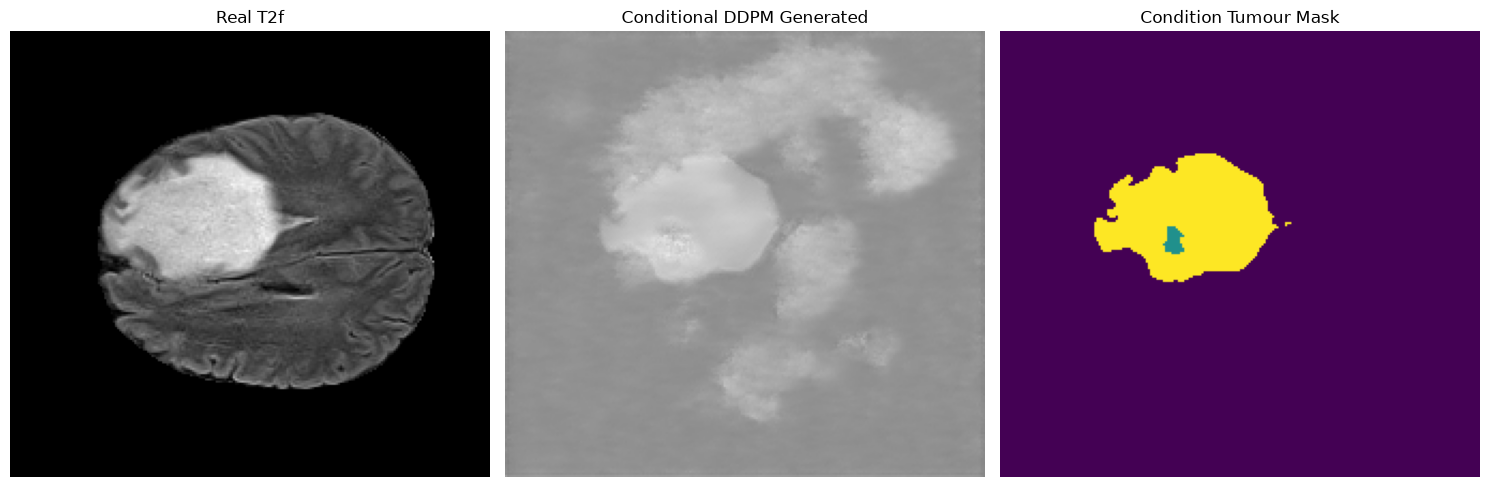

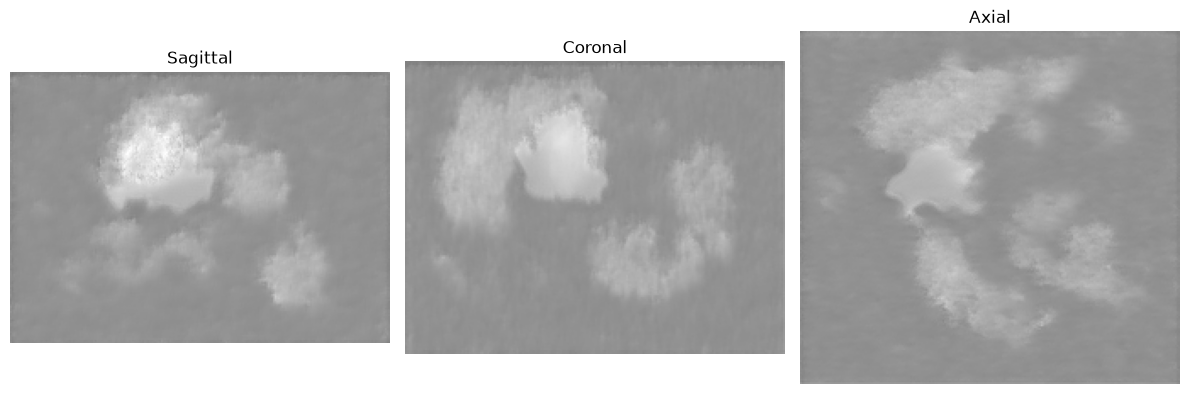


Generated statistics
Min: -0.10790229
Max: 0.99983406
Mean: 0.18478206
Std: 0.10888894


In [23]:
# ============================================================
# Conditional DDPM V2
# Load checkpoint + sample + visualize
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch


# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 2. Re-create model and optimizer
# ------------------------------------------------------------

model = ConditionalUNet3D(
    image_channels=1,
    mask_channels=3,
    out_channels=1,
    base_channels=16,
    time_dim=128
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


# ------------------------------------------------------------
# 3. Load trained epoch-10 checkpoint
# ------------------------------------------------------------

checkpoint_path = (
    "conditional_v2_checkpoints/"
    "conditional_ddpm_epoch_010.pt"
)

loaded_epoch = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path=checkpoint_path,
    device=device
)

print(
    "Loaded epoch:",
    loaded_epoch
)


# ------------------------------------------------------------
# 4. Choose one real subject to provide conditions
# ------------------------------------------------------------

sample = train_dataset[0]

real_image = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)

mask = (
    sample["mask"]
    .unsqueeze(0)
    .to(device)
)

heterogeneity = (
    sample["heterogeneity"]
    .unsqueeze(0)
    .to(device)
)

print(
    "Subject:",
    sample["subject"]
)

print(
    "Real image shape:",
    real_image.shape
)

print(
    "Mask shape:",
    mask.shape
)

print(
    "Mask labels:",
    torch.unique(mask)
)

print(
    "Raw entropy:",
    heterogeneity.item()
)


# ------------------------------------------------------------
# 5. Conditional DDPM sampling
# ------------------------------------------------------------

torch.manual_seed(42)

generated = sample_conditional_ddpm(
    model=model,
    shape=(
        1,
        1,
        208,
        224,
        160
    ),
    mask=mask,
    heterogeneity=heterogeneity,
    device=device
)


print(
    "Generated shape:",
    generated.shape
)

print(
    "Generated range:",
    generated.min().item(),
    generated.max().item()
)


# ------------------------------------------------------------
# 6. Convert [-1, 1] -> [0, 1]
# ------------------------------------------------------------

real_np = (
    real_image[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

generated_np = (
    generated[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

mask_np = (
    mask[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)


real_display = np.clip(
    (
        real_np + 1.0
    ) / 2.0,
    0.0,
    1.0
)

generated_display = np.clip(
    (
        generated_np + 1.0
    ) / 2.0,
    0.0,
    1.0
)


# ------------------------------------------------------------
# 7. Find slice containing most tumour
# ------------------------------------------------------------

tumour_per_slice = (
    mask_np > 0
).sum(
    axis=(0, 1)
)

tumour_slice = int(
    np.argmax(
        tumour_per_slice
    )
)

print(
    "Tumour-max slice:",
    tumour_slice
)


# ------------------------------------------------------------
# 8. Compare real / generated / condition mask
# ------------------------------------------------------------

plt.figure(
    figsize=(15, 5)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    real_display[
        :,
        :,
        tumour_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Real T2f"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    generated_display[
        :,
        :,
        tumour_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Conditional DDPM Generated"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    mask_np[
        :,
        :,
        tumour_slice
    ],
    cmap="viridis"
)

plt.title(
    "Condition Tumour Mask"
)

plt.axis(
    "off"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Orthogonal views of generated volume
# ------------------------------------------------------------

x_mid = (
    generated_display.shape[0]
    // 2
)

y_mid = (
    generated_display.shape[1]
    // 2
)

z_mid = (
    generated_display.shape[2]
    // 2
)


plt.figure(
    figsize=(12, 4)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    generated_display[
        x_mid,
        :,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Sagittal"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    generated_display[
        :,
        y_mid,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Coronal"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    generated_display[
        :,
        :,
        z_mid
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Axial"
)

plt.axis(
    "off"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Statistics
# ------------------------------------------------------------

print()
print("Generated statistics")

print(
    "Min:",
    generated_np.min()
)

print(
    "Max:",
    generated_np.max()
)

print(
    "Mean:",
    generated_np.mean()
)

print(
    "Std:",
    generated_np.std()
)

CONDITIONAL DDPM V2 DIAGNOSTIC
Device: cuda:0
Timesteps: [50, 100, 250, 500, 750, 999]

PART 1 — DIFFUSION SCHEDULE CONSISTENCY
Max alpha_cumprod difference: 0.0
RESULT: schedule consistency PASSED.

PART 2 — LOAD REAL SUBJECT
Subject: BraTS-GLI-00240-000
Image shape: (1, 1, 208, 224, 160)
Mask labels: tensor([0, 1, 2, 3], device='cuda:0')
Raw entropy: 7.390011310577393
Normalized entropy: 1.565505862236023
Brain foreground fraction: 0.1900
Air background fraction: 0.8100
Tumour fraction: 0.019320

PART 3 — EPSILON PREDICTION ERROR BY REGION
t= 50 | Whole=0.040632 | Brain=0.171782 | Air=0.009866 | Tumour=0.150080 | Brain/Air=17.41
t=100 | Whole=0.019351 | Brain=0.082697 | Air=0.004491 | Tumour=0.070876 | Brain/Air=18.41
t=250 | Whole=0.005873 | Brain=0.022083 | Air=0.002071 | Tumour=0.020532 | Brain/Air=10.66
t=500 | Whole=0.001950 | Brain=0.003988 | Air=0.001472 | Tumour=0.004479 | Brain/Air=2.71
t=750 | Whole=0.001399 | Brain=0.001402 | Air=0.001398 | Tumour=0.002631 | Brain/Air=1.00

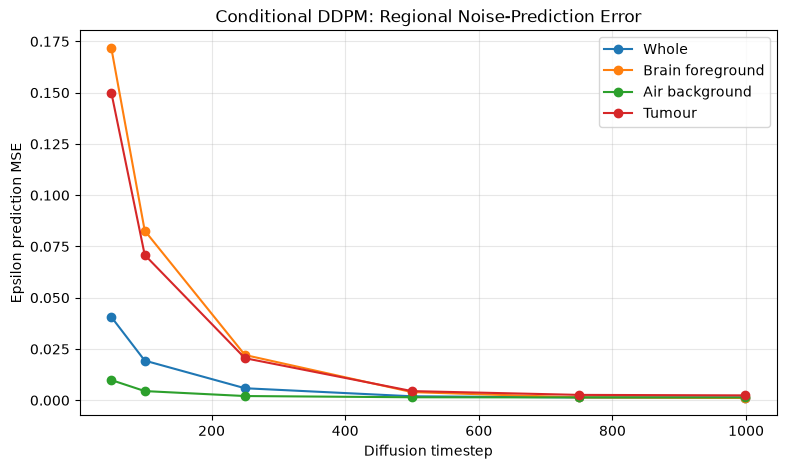


PART 4 — CONDITIONING SHORTCUT TEST

PART 5 — ENTROPY CONDITION SENSITIVITY

PART 6 — NUMERIC CONDITION SENSITIVITY
Correct vs zero-mask mean absolute difference: 0.06163924187421799
Correct vs shifted-mask mean absolute difference: 0.02139788493514061
Low vs high entropy mean absolute difference: 0.21304050087928772

PART 7 — BACKGROUND AIR BLEEDING
REAL AIR
Mean: -1.0
Std: 0.0
Min/Max: -1.0 -1.0

GENERATED AIR
Mean: 0.160114586353302
Std: 0.06988930702209473
Min/Max: -0.11076722294092178 0.7748953700065613

REAL BRAIN
Mean: -0.3043683171272278
Std: 0.3168458044528961

GENERATED BRAIN
Mean: 0.27218765020370483
Std: 0.1942373812198639

PART 8 — INTENSITY DISTRIBUTION CHECK
Percentile | Real brain | Generated brain
         1 |   -0.88235 |         0.11245
        10 |   -0.59041 |         0.12797
        25 |   -0.47712 |         0.14019
        50 |   -0.36819 |         0.17600
        75 |   -0.22440 |         0.34405
        90 |    0.09368 |         0.56506
        99 |    0.70370

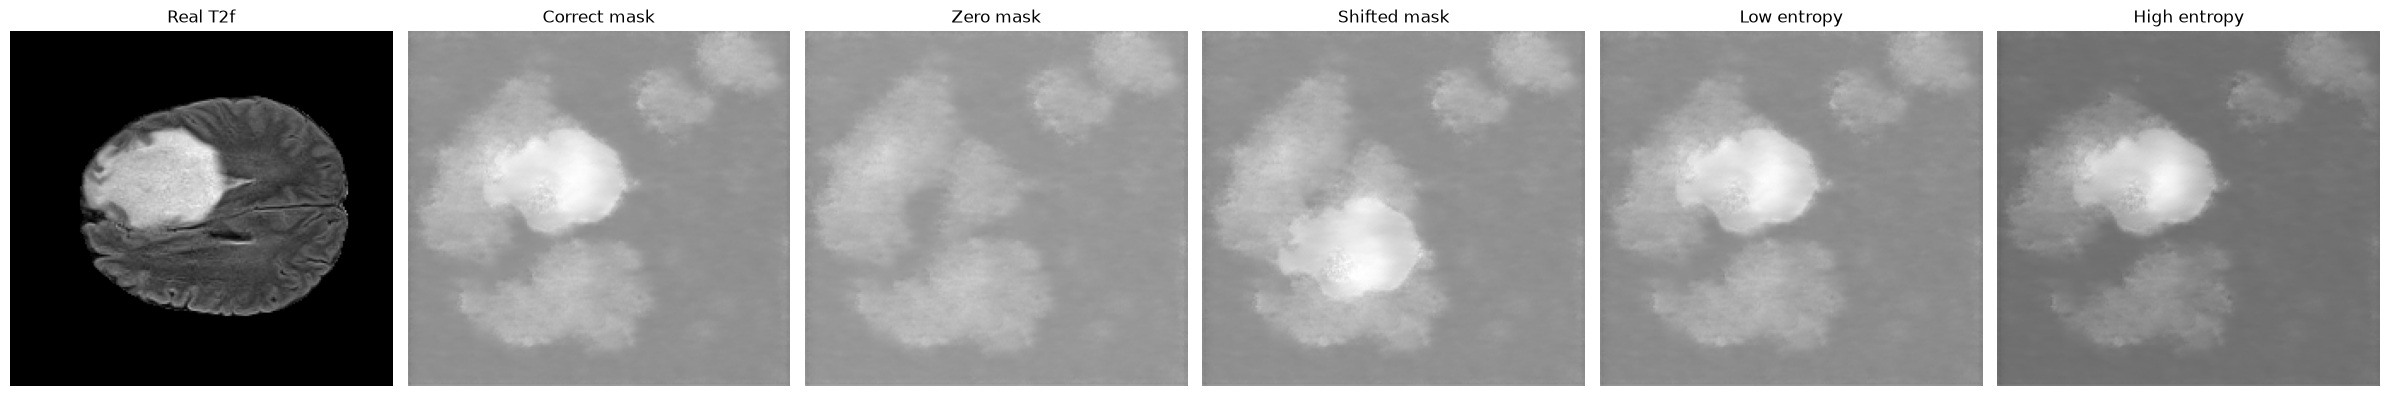


AUTOMATIC DIAGNOSTIC SUMMARY
Average brain epsilon MSE: 0.047178
Average air epsilon MSE: 0.003447
Average tumour epsilon MSE: 0.041831
Whole-volume MSE is likely masking poor anatomical learning.
Generated air mean is far above the training background value (-1).

Interpret the condition-comparison image:
- If bright structures follow the shifted mask, conditioning shortcut is likely.
- If zero-mask output still lacks a brain, global anatomical prior is weak.
- If low/high entropy outputs are nearly identical, heterogeneity conditioning is weak.
- If generated air remains grey instead of -1, background distribution learning has failed.


In [24]:
# ============================================================
# CONDITIONAL DDPM V2 - COMPREHENSIVE QUICK DIAGNOSTIC
#
# Checks:
# 1. Diffusion schedule consistency
# 2. Whole / brain / background / tumour epsilon MSE
# 3. Background air bleeding
# 4. Conditioning shortcut:
#       correct mask vs zero mask vs shifted mask
# 5. Entropy-condition sensitivity
# 6. Intensity distribution collapse / mean bias
#
# REQUIREMENTS:
# - train_dataset exists
# - model exists
# - epoch-10 checkpoint has already been loaded into model
# - q_sample() exists
# - sample_conditional_ddpm() exists
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

device = next(model.parameters()).device

model.eval()

diagnostic_timesteps = [
    50,
    100,
    250,
    500,
    750,
    999
]

entropy_mean = 6.870206
entropy_std = 0.3320367

print("=" * 72)
print("CONDITIONAL DDPM V2 DIAGNOSTIC")
print("=" * 72)
print("Device:", device)
print("Timesteps:", diagnostic_timesteps)


# ============================================================
# PART 1 — SCHEDULE CONSISTENCY
# ============================================================

print()
print("=" * 72)
print("PART 1 — DIFFUSION SCHEDULE CONSISTENCY")
print("=" * 72)

manual_alphas = 1.0 - betas

manual_alphas_cumprod = torch.cumprod(
    manual_alphas,
    dim=0
)

alpha_diff = torch.max(
    torch.abs(
        manual_alphas_cumprod
        - alphas_cumprod
    )
).item()

print(
    "Max alpha_cumprod difference:",
    alpha_diff
)

if alpha_diff < 1e-7:
    print(
        "RESULT: schedule consistency PASSED."
    )
else:
    print(
        "WARNING: schedule inconsistency detected."
    )


# ============================================================
# PART 2 — LOAD ONE REAL SUBJECT
# ============================================================

print()
print("=" * 72)
print("PART 2 — LOAD REAL SUBJECT")
print("=" * 72)

sample = train_dataset[0]

x0 = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)

mask = (
    sample["mask"]
    .unsqueeze(0)
    .to(device)
)

raw_entropy = (
    sample["heterogeneity"]
    .unsqueeze(0)
    .to(device)
    .float()
)

normalized_entropy = (
    raw_entropy - entropy_mean
) / entropy_std

print(
    "Subject:",
    sample["subject"]
)

print(
    "Image shape:",
    tuple(x0.shape)
)

print(
    "Mask labels:",
    torch.unique(mask)
)

print(
    "Raw entropy:",
    raw_entropy.item()
)

print(
    "Normalized entropy:",
    normalized_entropy.item()
)


# ------------------------------------------------------------
# Masks for diagnostic regions
#
# IMPORTANT:
# Real training background is exactly -1
# after preprocessing.
# ------------------------------------------------------------

brain_mask = (
    x0 > -0.999
)

air_mask = (
    ~brain_mask
)

tumour_mask = (
    mask > 0
)

brain_fraction = (
    brain_mask.float()
    .mean()
    .item()
)

air_fraction = (
    air_mask.float()
    .mean()
    .item()
)

tumour_fraction = (
    tumour_mask.float()
    .mean()
    .item()
)

print(
    f"Brain foreground fraction: "
    f"{brain_fraction:.4f}"
)

print(
    f"Air background fraction: "
    f"{air_fraction:.4f}"
)

print(
    f"Tumour fraction: "
    f"{tumour_fraction:.6f}"
)


# ============================================================
# PART 3 — EPSILON MSE BY REGION
# ============================================================

print()
print("=" * 72)
print("PART 3 — EPSILON PREDICTION ERROR BY REGION")
print("=" * 72)

region_results = []

with torch.no_grad():

    for t_value in diagnostic_timesteps:

        t = torch.full(
            (1,),
            t_value,
            device=device,
            dtype=torch.long
        )

        noise = torch.randn_like(
            x0
        )

        xt, _ = q_sample(
            x0=x0,
            t=t,
            noise=noise
        )

        predicted_noise = model(
            xt,
            t,
            mask,
            normalized_entropy
        )

        squared_error = (
            predicted_noise
            - noise
        ) ** 2

        whole_mse = (
            squared_error.mean()
            .item()
        )

        brain_mse = (
            squared_error[
                brain_mask
            ]
            .mean()
            .item()
        )

        air_mse = (
            squared_error[
                air_mask
            ]
            .mean()
            .item()
        )

        tumour_mse = (
            squared_error[
                tumour_mask
            ]
            .mean()
            .item()
        )

        region_results.append(
            {
                "t": t_value,
                "whole": whole_mse,
                "brain": brain_mse,
                "air": air_mse,
                "tumour": tumour_mse
            }
        )

        print(
            f"t={t_value:3d} | "
            f"Whole={whole_mse:.6f} | "
            f"Brain={brain_mse:.6f} | "
            f"Air={air_mse:.6f} | "
            f"Tumour={tumour_mse:.6f} | "
            f"Brain/Air="
            f"{brain_mse / max(air_mse, 1e-12):.2f}"
        )


# ------------------------------------------------------------
# Plot regional errors
# ------------------------------------------------------------

ts = [
    r["t"]
    for r in region_results
]

whole_losses = [
    r["whole"]
    for r in region_results
]

brain_losses = [
    r["brain"]
    for r in region_results
]

air_losses = [
    r["air"]
    for r in region_results
]

tumour_losses = [
    r["tumour"]
    for r in region_results
]

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    ts,
    whole_losses,
    marker="o",
    label="Whole"
)

plt.plot(
    ts,
    brain_losses,
    marker="o",
    label="Brain foreground"
)

plt.plot(
    ts,
    air_losses,
    marker="o",
    label="Air background"
)

plt.plot(
    ts,
    tumour_losses,
    marker="o",
    label="Tumour"
)

plt.xlabel(
    "Diffusion timestep"
)

plt.ylabel(
    "Epsilon prediction MSE"
)

plt.title(
    "Conditional DDPM: Regional Noise-Prediction Error"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# PART 4 — CONDITIONING SHORTCUT TEST
# ============================================================

print()
print("=" * 72)
print("PART 4 — CONDITIONING SHORTCUT TEST")
print("=" * 72)

# Correct mask
correct_mask = mask.clone()

# Completely remove tumour condition
zero_mask = torch.zeros_like(
    mask
)

# Shift the tumour mask spatially
shifted_mask = torch.roll(
    mask,
    shifts=40,
    dims=2
)

# Use same seed before every complete sampling
# so differences mainly come from conditions.

torch.manual_seed(1234)

generated_correct = sample_conditional_ddpm(
    model=model,
    shape=(
        1,
        1,
        208,
        224,
        160
    ),
    mask=correct_mask,
    heterogeneity=raw_entropy,
    device=device
)

torch.manual_seed(1234)

generated_zero = sample_conditional_ddpm(
    model=model,
    shape=(
        1,
        1,
        208,
        224,
        160
    ),
    mask=zero_mask,
    heterogeneity=raw_entropy,
    device=device
)

torch.manual_seed(1234)

generated_shifted = sample_conditional_ddpm(
    model=model,
    shape=(
        1,
        1,
        208,
        224,
        160
    ),
    mask=shifted_mask,
    heterogeneity=raw_entropy,
    device=device
)


# ============================================================
# PART 5 — ENTROPY SENSITIVITY TEST
# ============================================================

print()
print("=" * 72)
print("PART 5 — ENTROPY CONDITION SENSITIVITY")
print("=" * 72)

# +/- 2 standard deviations from this subject's
# normalized entropy value.

low_entropy_raw = (
    raw_entropy
    - 2.0 * entropy_std
)

high_entropy_raw = (
    raw_entropy
    + 2.0 * entropy_std
)

torch.manual_seed(1234)

generated_low_entropy = (
    sample_conditional_ddpm(
        model=model,
        shape=(
            1,
            1,
            208,
            224,
            160
        ),
        mask=correct_mask,
        heterogeneity=low_entropy_raw,
        device=device
    )
)

torch.manual_seed(1234)

generated_high_entropy = (
    sample_conditional_ddpm(
        model=model,
        shape=(
            1,
            1,
            208,
            224,
            160
        ),
        mask=correct_mask,
        heterogeneity=high_entropy_raw,
        device=device
    )
)


# ============================================================
# PART 6 — NUMERIC CONDITION SENSITIVITY
# ============================================================

print()
print("=" * 72)
print("PART 6 — NUMERIC CONDITION SENSITIVITY")
print("=" * 72)

mask_zero_difference = (
    torch.mean(
        torch.abs(
            generated_correct
            - generated_zero
        )
    )
    .item()
)

mask_shift_difference = (
    torch.mean(
        torch.abs(
            generated_correct
            - generated_shifted
        )
    )
    .item()
)

entropy_difference = (
    torch.mean(
        torch.abs(
            generated_low_entropy
            - generated_high_entropy
        )
    )
    .item()
)

print(
    "Correct vs zero-mask mean absolute difference:",
    mask_zero_difference
)

print(
    "Correct vs shifted-mask mean absolute difference:",
    mask_shift_difference
)

print(
    "Low vs high entropy mean absolute difference:",
    entropy_difference
)


# ============================================================
# PART 7 — BACKGROUND AIR BLEEDING
# ============================================================

print()
print("=" * 72)
print("PART 7 — BACKGROUND AIR BLEEDING")
print("=" * 72)

generated = generated_correct

real_air_values = (
    x0[
        air_mask
    ]
)

generated_air_values = (
    generated[
        air_mask
    ]
)

real_brain_values = (
    x0[
        brain_mask
    ]
)

generated_brain_values = (
    generated[
        brain_mask
    ]
)

print(
    "REAL AIR"
)

print(
    "Mean:",
    real_air_values.mean().item()
)

print(
    "Std:",
    real_air_values.std().item()
)

print(
    "Min/Max:",
    real_air_values.min().item(),
    real_air_values.max().item()
)

print()

print(
    "GENERATED AIR"
)

print(
    "Mean:",
    generated_air_values.mean().item()
)

print(
    "Std:",
    generated_air_values.std().item()
)

print(
    "Min/Max:",
    generated_air_values.min().item(),
    generated_air_values.max().item()
)

print()

print(
    "REAL BRAIN"
)

print(
    "Mean:",
    real_brain_values.mean().item()
)

print(
    "Std:",
    real_brain_values.std().item()
)

print()

print(
    "GENERATED BRAIN"
)

print(
    "Mean:",
    generated_brain_values.mean().item()
)

print(
    "Std:",
    generated_brain_values.std().item()
)


# ============================================================
# PART 8 — DISTRIBUTION / REGRESSION-TO-MEAN CHECK
# ============================================================

print()
print("=" * 72)
print("PART 8 — INTENSITY DISTRIBUTION CHECK")
print("=" * 72)

real_brain_np = (
    real_brain_values
    .detach()
    .cpu()
    .numpy()
)

generated_brain_np = (
    generated_brain_values
    .detach()
    .cpu()
    .numpy()
)

percentiles = [
    1,
    10,
    25,
    50,
    75,
    90,
    99
]

print("Percentile | Real brain | Generated brain")

for p in percentiles:

    real_p = np.percentile(
        real_brain_np,
        p
    )

    generated_p = np.percentile(
        generated_brain_np,
        p
    )

    print(
        f"{p:>10} | "
        f"{real_p:10.5f} | "
        f"{generated_p:15.5f}"
    )

std_ratio = (
    generated_brain_values.std().item()
    / max(
        real_brain_values.std().item(),
        1e-12
    )
)

print()

print(
    "Generated / Real brain std ratio:",
    std_ratio
)

if std_ratio < 0.5:
    print(
        "WARNING: generated foreground intensity "
        "variation is strongly compressed."
    )

    print(
        "This supports an over-smoothed / "
        "mean-biased distribution."
    )
else:
    print(
        "No extreme foreground variance collapse detected."
    )


# ============================================================
# PART 9 — VISUAL CONDITION COMPARISON
# ============================================================

def to_display(tensor):

    volume = (
        tensor[
            0,
            0
        ]
        .detach()
        .cpu()
        .numpy()
    )

    return np.clip(
        (
            volume + 1.0
        ) / 2.0,
        0.0,
        1.0
    )


real_display = to_display(
    x0
)

correct_display = to_display(
    generated_correct
)

zero_display = to_display(
    generated_zero
)

shifted_display = to_display(
    generated_shifted
)

low_entropy_display = to_display(
    generated_low_entropy
)

high_entropy_display = to_display(
    generated_high_entropy
)


mask_np = (
    mask[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

tumour_per_slice = (
    mask_np > 0
).sum(
    axis=(0, 1)
)

tumour_slice = int(
    np.argmax(
        tumour_per_slice
    )
)

print(
    "Tumour-max slice:",
    tumour_slice
)


plt.figure(
    figsize=(24, 4)
)

images = [
    real_display,
    correct_display,
    zero_display,
    shifted_display,
    low_entropy_display,
    high_entropy_display
]

titles = [
    "Real T2f",
    "Correct mask",
    "Zero mask",
    "Shifted mask",
    "Low entropy",
    "High entropy"
]

for i, (
    image,
    title
) in enumerate(
    zip(
        images,
        titles
    )
):

    plt.subplot(
        1,
        6,
        i + 1
    )

    plt.imshow(
        image[
            :,
            :,
            tumour_slice
        ],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        title
    )

    plt.axis(
        "off"
    )

plt.tight_layout()

plt.show()


# ============================================================
# PART 10 — AUTOMATIC SUMMARY
# ============================================================

print()
print("=" * 72)
print("AUTOMATIC DIAGNOSTIC SUMMARY")
print("=" * 72)


avg_brain_mse = np.mean(
    brain_losses
)

avg_air_mse = np.mean(
    air_losses
)

avg_tumour_mse = np.mean(
    tumour_losses
)


print(
    f"Average brain epsilon MSE: "
    f"{avg_brain_mse:.6f}"
)

print(
    f"Average air epsilon MSE: "
    f"{avg_air_mse:.6f}"
)

print(
    f"Average tumour epsilon MSE: "
    f"{avg_tumour_mse:.6f}"
)


if avg_brain_mse > (
    2.0 * avg_air_mse
):

    print(
        "WARNING: brain-region error is >2x "
        "air-background error."
    )

    print(
        "Whole-volume MSE is likely masking "
        "poor anatomical learning."
    )


generated_air_mean = (
    generated_air_values
    .mean()
    .item()
)

if generated_air_mean > -0.8:

    print(
        "WARNING: strong background air bleeding detected."
    )

    print(
        "Generated air mean is far above "
        "the training background value (-1)."
    )


if mask_zero_difference > (
    entropy_difference * 2.0
):

    print(
        "Mask condition has much stronger effect "
        "than entropy condition."
    )


if entropy_difference < 0.01:

    print(
        "WARNING: entropy conditioning appears weak "
        "or nearly ignored."
    )


print()
print(
    "Interpret the condition-comparison image:"
)

print(
    "- If bright structures follow the shifted mask, "
    "conditioning shortcut is likely."
)

print(
    "- If zero-mask output still lacks a brain, "
    "global anatomical prior is weak."
)

print(
    "- If low/high entropy outputs are nearly identical, "
    "heterogeneity conditioning is weak."
)

print(
    "- If generated air remains grey instead of -1, "
    "background distribution learning has failed."
)

print("=" * 72)